In [1]:
# Imports and load all datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve)
from sklearn.preprocessing import label_binarize
import pickle

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_PATH = r"data\processed"
SYNTHETIC_PATH = r"data\synthetic"
FIGURES_PATH   = r"results\figures"
RESULTS_PATH   = r"results"

os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# ── Load all datasets ──────────────────────────────────────────────────
train_real    = pd.read_csv(os.path.join(PROCESSED_PATH,  'train_real.csv'))
test_real     = pd.read_csv(os.path.join(PROCESSED_PATH,  'test_real.csv'))
syn_ctgan     = pd.read_csv(os.path.join(SYNTHETIC_PATH,  'synthetic_ctgan.csv'))
syn_tabddpm   = pd.read_csv(os.path.join(SYNTHETIC_PATH,  'synthetic_tabddpm.csv'))

# ── Feature columns (exclude target) ──────────────────────────────────
feature_cols  = [c for c in train_real.columns
                 if c != 'HOSPITAL_EXPIRE_FLAG']
target_col    = 'HOSPITAL_EXPIRE_FLAG'

print(f"✓ All datasets loaded")
print(f"  Real train:      {train_real.shape}")
print(f"  Real test:       {test_real.shape}")
print(f"  CTGAN synthetic: {syn_ctgan.shape}")
print(f"  TabDDPM synth:   {syn_tabddpm.shape}")
print(f"  Features:        {len(feature_cols)}")

✓ All datasets loaded
  Real train:      (25508, 34)
  Real test:       (6377, 34)
  CTGAN synthetic: (25508, 34)
  TabDDPM synth:   (25508, 34)
  Features:        33


In [2]:
# Column-wise statistical comparison
# Compare mean and std of every feature
# between real and synthetic datasets

print("Computing column-wise statistics...")

results_stats = []

for col in feature_cols:
    real_mean   = train_real[col].mean()
    real_std    = train_real[col].std()
    ctgan_mean  = syn_ctgan[col].mean()
    ctgan_std   = syn_ctgan[col].std()
    tab_mean    = syn_tabddpm[col].mean()
    tab_std     = syn_tabddpm[col].std()

    results_stats.append({
        'feature':       col,
        'real_mean':     round(real_mean,  4),
        'ctgan_mean':    round(ctgan_mean, 4),
        'tabddpm_mean':  round(tab_mean,   4),
        'real_std':      round(real_std,   4),
        'ctgan_std':     round(ctgan_std,  4),
        'tabddpm_std':   round(tab_std,    4),
        'ctgan_mean_err':  round(abs(real_mean - ctgan_mean), 4),
        'tabddpm_mean_err':round(abs(real_mean - tab_mean),   4),
    })

stats_df = pd.DataFrame(results_stats)

print("\nMean Absolute Error — Real vs Synthetic (per feature):")
print(f"{'Feature':<30} {'CTGAN err':>12} {'TabDDPM err':>12} {'Winner':>10}")
print("-" * 68)

for _, row in stats_df.iterrows():
    winner = 'TabDDPM' if row['tabddpm_mean_err'] < row['ctgan_mean_err'] \
             else 'CTGAN'
    print(f"{row['feature']:<30} "
          f"{row['ctgan_mean_err']:>12.4f} "
          f"{row['tabddpm_mean_err']:>12.4f} "
          f"{winner:>10}")

print(f"\nOverall mean error — CTGAN:   "
      f"{stats_df['ctgan_mean_err'].mean():.4f}")
print(f"Overall mean error — TabDDPM: "
      f"{stats_df['tabddpm_mean_err'].mean():.4f}")

# Save
stats_df.to_csv(os.path.join(RESULTS_PATH, 'column_statistics.csv'),
                index=False)
print(f"\n Column statistics saved")

Computing column-wise statistics...

Mean Absolute Error — Real vs Synthetic (per feature):
Feature                           CTGAN err  TabDDPM err     Winner
--------------------------------------------------------------------
AGE                                  0.0786       0.0013    TabDDPM
GENDER                               0.0703       0.0002    TabDDPM
LOS                                  0.1153       0.0037    TabDDPM
lab_base_excess                      0.1599       0.0036    TabDDPM
lab_bicarbonate                      0.0244       0.0158    TabDDPM
lab_bun                              0.1794       0.0022    TabDDPM
lab_creatinine                       0.0527       0.0123    TabDDPM
lab_glucose                          0.1114       0.0075    TabDDPM
lab_haemoglobin                      0.0415       0.0039    TabDDPM
lab_lactate                          0.0169       0.0230      CTGAN
lab_ph                               0.1308       0.0055    TabDDPM
lab_platelets          

In [3]:
# Jensen-Shannon Divergence (JSD)
# Measures how different two probability distributions are
# JSD = 0 means identical, JSD = 1 means completely different
# Lower is better for synthetic data

def compute_jsd(real_col, syn_col, bins=50):
    """Compute JSD between real and synthetic column distributions."""
    min_val = min(real_col.min(), syn_col.min())
    max_val = max(real_col.max(), syn_col.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)

    real_hist, _ = np.histogram(real_col, bins=bin_edges, density=True)
    syn_hist,  _ = np.histogram(syn_col,  bins=bin_edges, density=True)

    # Add small epsilon to avoid log(0)
    real_hist = real_hist + 1e-10
    syn_hist  = syn_hist  + 1e-10

    # Normalise
    real_hist = real_hist / real_hist.sum()
    syn_hist  = syn_hist  / syn_hist.sum()

    return jensenshannon(real_hist, syn_hist)

print("Computing Jensen-Shannon Divergence per feature...")
print(f"\n{'Feature':<30} {'CTGAN JSD':>12} {'TabDDPM JSD':>12} {'Winner':>10}")
print("-" * 68)

jsd_results = []

for col in feature_cols:
    jsd_ctgan  = compute_jsd(train_real[col], syn_ctgan[col])
    jsd_tabddpm = compute_jsd(train_real[col], syn_tabddpm[col])
    winner = 'TabDDPM' if jsd_tabddpm < jsd_ctgan else 'CTGAN'

    jsd_results.append({
        'feature':      col,
        'ctgan_jsd':    round(jsd_ctgan,   4),
        'tabddpm_jsd':  round(jsd_tabddpm, 4),
        'winner':       winner
    })

    print(f"{col:<30} {jsd_ctgan:>12.4f} "
          f"{jsd_tabddpm:>12.4f} {winner:>10}")

jsd_df = pd.DataFrame(jsd_results)

print(f"\nMean JSD — CTGAN:   {jsd_df['ctgan_jsd'].mean():.4f}")
print(f"Mean JSD — TabDDPM: {jsd_df['tabddpm_jsd'].mean():.4f}")

jsd_df.to_csv(os.path.join(RESULTS_PATH, 'jsd_scores.csv'), index=False)
print(f"\n JSD scores saved")

Computing Jensen-Shannon Divergence per feature...

Feature                           CTGAN JSD  TabDDPM JSD     Winner
--------------------------------------------------------------------
AGE                                  0.1139       0.0237    TabDDPM
GENDER                               0.0511       0.0002    TabDDPM
LOS                                  0.1058       0.0301    TabDDPM
lab_base_excess                      0.1929       0.1434    TabDDPM
lab_bicarbonate                      0.2125       0.1424    TabDDPM
lab_bun                              0.1314       0.0616    TabDDPM
lab_creatinine                       0.1758       0.1744    TabDDPM
lab_glucose                          0.1497       0.0772    TabDDPM
lab_haemoglobin                      0.1206       0.0576    TabDDPM
lab_lactate                          0.2528       0.1829    TabDDPM
lab_ph                               0.4069       0.3893    TabDDPM
lab_platelets                        0.1148       0.0558    Tab

In [4]:
# Maximum Mean Discrepancy (MMD)
# Kernel-based distance between two distributions in feature space
# MMD close to 0 = synthetic data matches real data well
# Computed on a sample for speed

def compute_mmd(X_real, X_syn, gamma=1.0, sample_size=2000):
    """RBF kernel MMD between real and synthetic feature matrices."""
    from sklearn.metrics.pairwise import rbf_kernel

    # Sample for speed
    idx_r = np.random.choice(len(X_real), 
                              min(sample_size, len(X_real)),
                              replace=False)
    idx_s = np.random.choice(len(X_syn),
                              min(sample_size, len(X_syn)),
                              replace=False)

    Xr = X_real[idx_r]
    Xs = X_syn[idx_s]

    K_rr = rbf_kernel(Xr, Xr, gamma)
    K_ss = rbf_kernel(Xs, Xs, gamma)
    K_rs = rbf_kernel(Xr, Xs, gamma)

    return K_rr.mean() + K_ss.mean() - 2 * K_rs.mean()

# Use only continuous features for MMD
continuous_cols = ['AGE', 'LOS'] + \
                  [c for c in feature_cols if c.startswith('lab_')
                   and not c.endswith('_missing')]

X_real   = train_real[continuous_cols].values
X_ctgan  = syn_ctgan[continuous_cols].values
X_tabddpm = syn_tabddpm[continuous_cols].values

mmd_ctgan   = compute_mmd(X_real, X_ctgan)
mmd_tabddpm = compute_mmd(X_real, X_tabddpm)

print(f"Maximum Mean Discrepancy (MMD):")
print(f"  CTGAN:   {mmd_ctgan:.6f}")
print(f"  TabDDPM: {mmd_tabddpm:.6f}")
print(f"  Winner:  {'TabDDPM' if mmd_tabddpm < mmd_ctgan else 'CTGAN'}")
print(f"\n  Lower MMD = better = synthetic closer to real")

Maximum Mean Discrepancy (MMD):
  CTGAN:   0.001654
  TabDDPM: 0.001032
  Winner:  TabDDPM

  Lower MMD = better = synthetic closer to real


Correlation Matrix Frobenius Norm:
  CTGAN:   2.2336
  TabDDPM: 0.7494
  Winner:  TabDDPM

  Lower = correlation structure better preserved


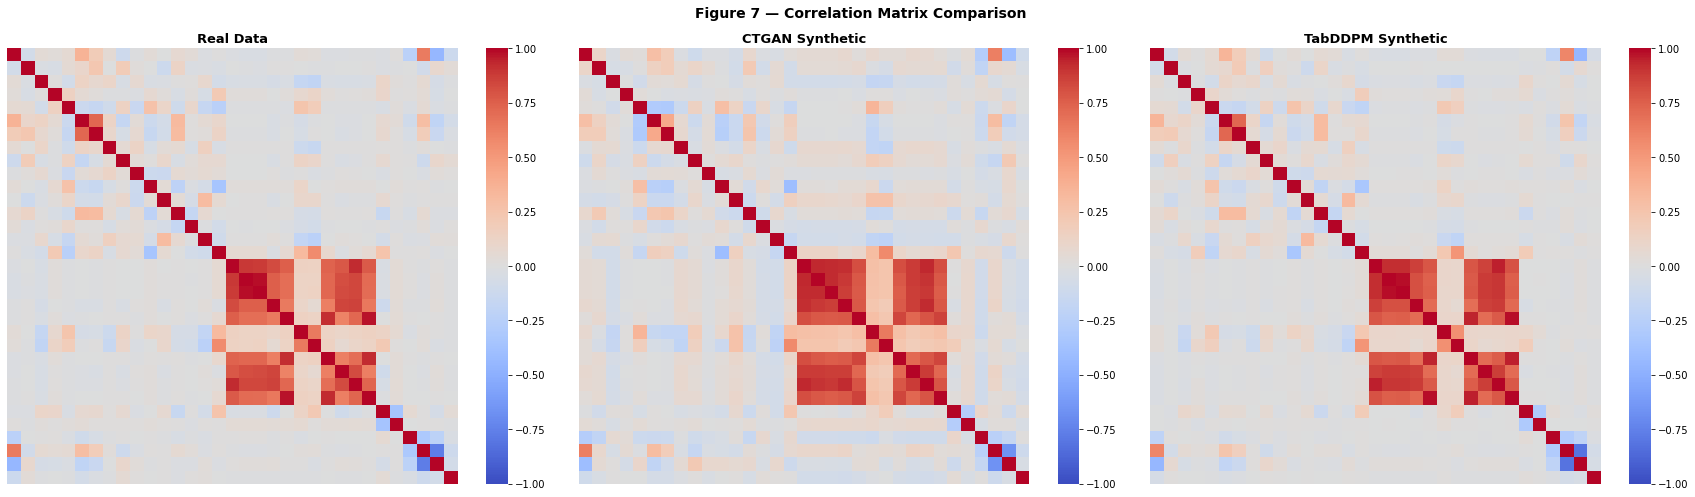

 Correlation comparison saved


In [5]:
# Correlation structure comparison
# Your generative model must preserve feature correlations
# e.g. creatinine and BUN should be positively correlated
# Frobenius norm measures how different two matrices are

real_corr   = train_real[feature_cols].corr()
ctgan_corr  = syn_ctgan[feature_cols].corr()
tabddpm_corr = syn_tabddpm[feature_cols].corr()

frob_ctgan   = np.linalg.norm(real_corr.values - ctgan_corr.values,  'fro')
frob_tabddpm = np.linalg.norm(real_corr.values - tabddpm_corr.values,'fro')

print(f"Correlation Matrix Frobenius Norm:")
print(f"  CTGAN:   {frob_ctgan:.4f}")
print(f"  TabDDPM: {frob_tabddpm:.4f}")
print(f"  Winner:  {'TabDDPM' if frob_tabddpm < frob_ctgan else 'CTGAN'}")
print(f"\n  Lower = correlation structure better preserved")

# Plot correlation matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, corr, title in zip(
    axes,
    [real_corr, ctgan_corr, tabddpm_corr],
    ['Real Data', 'CTGAN Synthetic', 'TabDDPM Synthetic']
):
    sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, annot=False,
                xticklabels=False, yticklabels=False)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Figure 7 — Correlation Matrix Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'correlation_comparison.png'),
            bbox_inches='tight')
plt.show()
print(" Correlation comparison saved")

In [6]:
# Train on Synthetic Test on Real (TSTR)
# The gold standard for synthetic data utility
# Train a classifier on synthetic data only
# Evaluate on real held-out test set
# Compare to training on real data (upper bound)

print("=" * 55)
print("  TSTR — Train on Synthetic, Test on Real")
print("=" * 55)

X_test  = test_real[feature_cols].values
y_test  = test_real[target_col].values

X_train_real   = train_real[feature_cols].values
y_train_real   = train_real[target_col].values

X_train_ctgan  = syn_ctgan[feature_cols].values
y_train_ctgan  = syn_ctgan[target_col].values

X_train_tabddpm = syn_tabddpm[feature_cols].values
y_train_tabddpm = syn_tabddpm[target_col].values

tstr_results = []

for train_name, X_tr, y_tr in [
    ('Real (upper bound)', X_train_real,    y_train_real),
    ('CTGAN',              X_train_ctgan,   y_train_ctgan),
    ('TabDDPM',            X_train_tabddpm, y_train_tabddpm)
]:
    # Use Random Forest — robust, no scaling needed
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)

    y_prob = clf.predict_proba(X_test)[:, 1]
    auroc  = roc_auc_score(y_test, y_prob)
    auprc  = average_precision_score(y_test, y_prob)

    tstr_results.append({
        'Training Data': train_name,
        'AUROC':         round(auroc, 4),
        'AUPRC':         round(auprc, 4)
    })

    print(f"\n  {train_name}")
    print(f"    AUROC: {auroc:.4f}")
    print(f"    AUPRC: {auprc:.4f}")

tstr_df = pd.DataFrame(tstr_results)
tstr_df.to_csv(os.path.join(RESULTS_PATH, 'tstr_results.csv'), index=False)
print(f"\n TSTR results saved")

  TSTR — Train on Synthetic, Test on Real

  Real (upper bound)
    AUROC: 0.8084
    AUPRC: 0.3682

  CTGAN
    AUROC: 0.7091
    AUPRC: 0.2230

  TabDDPM
    AUROC: 0.7826
    AUPRC: 0.3111

 TSTR results saved


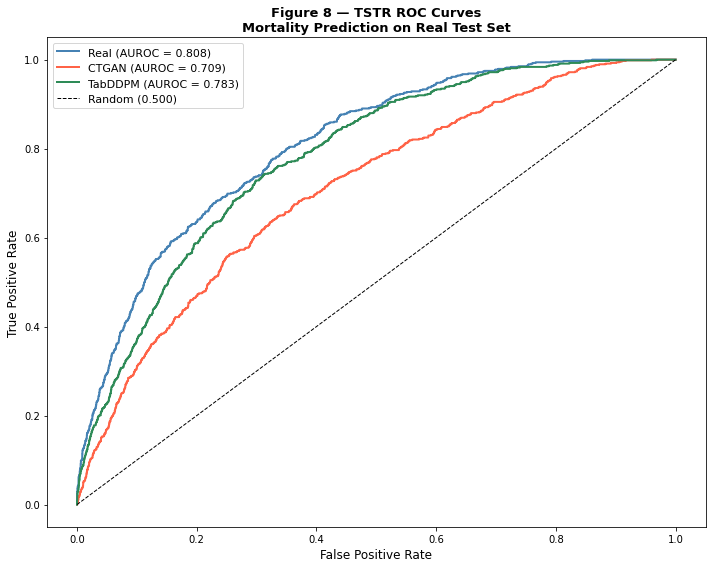

 ROC curve plot saved


In [7]:
# ROC curves for all three classifiers
# Visual comparison of classifier performance on real test set

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['steelblue', 'tomato', 'seagreen']
labels = ['Real (upper bound)', 'CTGAN', 'TabDDPM']

for (train_name, X_tr, y_tr), color in zip([
    ('Real',    X_train_real,    y_train_real),
    ('CTGAN',   X_train_ctgan,   y_train_ctgan),
    ('TabDDPM', X_train_tabddpm, y_train_tabddpm)
], colors):
    clf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_test)[:, 1]
    auroc  = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{train_name} (AUROC = {auroc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 8 — TSTR ROC Curves\n'
             'Mortality Prediction on Real Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'tstr_roc_curves.png'),
            bbox_inches='tight')
plt.show()
print(" ROC curve plot saved")

In [8]:
# Membership Inference Attack (MIA)
# Tests whether an attacker can tell if a real patient
# was in the training data by looking at synthetic data
# AUROC close to 0.5 = good privacy (attacker guessing randomly)
# AUROC above 0.7   = poor privacy (model memorising real patients)

print("=" * 55)
print("  PRIVACY — Membership Inference Attack")
print("=" * 55)

from sklearn.neighbors import NearestNeighbors

def nearest_neighbour_distance(X_query, X_reference):
    """Find distance from each query point to its nearest neighbour."""
    nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
    nn.fit(X_reference)
    distances, _ = nn.kneighbors(X_query)
    return distances.flatten()

# Use continuous features only for distance computation
cont_cols = ['AGE', 'LOS'] + \
            [c for c in feature_cols if c.startswith('lab_')
             and not c.endswith('_missing')]

X_train_r = train_real[cont_cols].values
X_test_r  = test_real[cont_cols].values

mia_results = {}

for syn_name, X_syn in [('CTGAN', syn_ctgan[cont_cols].values),
                          ('TabDDPM', syn_tabddpm[cont_cols].values)]:
    print(f"\n  Running MIA for {syn_name}...")

    # Distance of train members to synthetic
    dist_train = nearest_neighbour_distance(X_train_r, X_syn)
    # Distance of test non-members to synthetic
    dist_test  = nearest_neighbour_distance(X_test_r,  X_syn)

    # Members (train) should be closer to synthetic if memorised
    # Label: 1 = member (train), 0 = non-member (test)
    distances = np.concatenate([dist_train, dist_test])
    labels    = np.array([1]*len(dist_train) + [0]*len(dist_test))

    # Attack: closer to synthetic = more likely to be a member
    # We negate distance so higher score = more likely member
    attack_scores = -distances

    mia_auroc = roc_auc_score(labels, attack_scores)
    mia_results[syn_name] = mia_auroc

    print(f"    MIA AUROC: {mia_auroc:.4f}")
    if mia_auroc < 0.55:
        print(f"    ✓ Strong privacy — attacker near random chance")
    elif mia_auroc < 0.65:
        print(f"    ⚠ Moderate privacy — some signal detected")
    else:
        print(f"    ✗ Weak privacy — model may be memorising")

print(f"\n MIA complete")
print(f"  CTGAN   MIA AUROC: {mia_results['CTGAN']:.4f}")
print(f"  TabDDPM MIA AUROC: {mia_results['TabDDPM']:.4f}")
print(f"  Target: close to 0.500")

  PRIVACY — Membership Inference Attack

  Running MIA for CTGAN...
    MIA AUROC: 0.5067
    ✓ Strong privacy — attacker near random chance

  Running MIA for TabDDPM...
    MIA AUROC: 0.5039
    ✓ Strong privacy — attacker near random chance

 MIA complete
  CTGAN   MIA AUROC: 0.5067
  TabDDPM MIA AUROC: 0.5039
  Target: close to 0.500


Computing Distance to Closest Record (DCR)...

  CTGAN:
    5th percentile DCR:    0.5789
    Median DCR:            1.6830
    ✓ Good

  TabDDPM:
    5th percentile DCR:    1.0180
    Median DCR:            1.7295
    ✓ Good


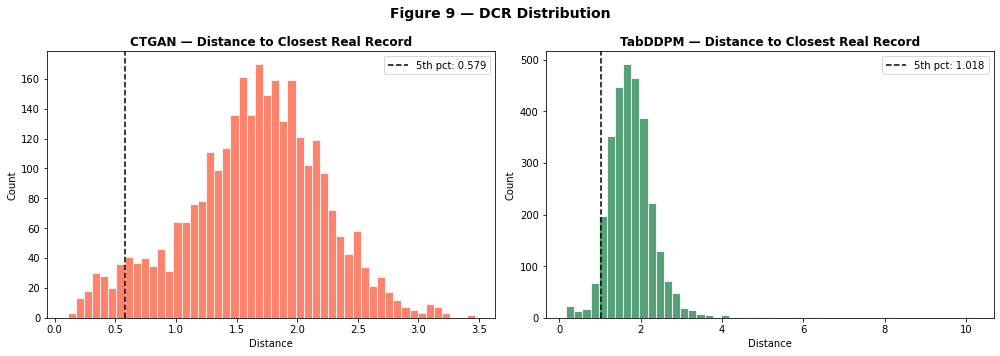


 DCR analysis saved


In [9]:
# Distance to Closest Record (DCR)
# For each synthetic record, find its nearest real neighbour
# Very small distances = synthetic record too close to a real patient
# 5th percentile DCR reported — higher is better

print("Computing Distance to Closest Record (DCR)...")

dcr_results = {}

for syn_name, X_syn in [('CTGAN',   syn_ctgan[cont_cols].values),
                          ('TabDDPM', syn_tabddpm[cont_cols].values)]:

    # Sample for speed
    sample_idx = np.random.choice(len(X_syn), 3000, replace=False)
    X_syn_sample = X_syn[sample_idx]

    dcr = nearest_neighbour_distance(X_syn_sample, X_train_r)

    p5  = np.percentile(dcr, 5)
    p50 = np.percentile(dcr, 50)
    dcr_results[syn_name] = {'p5': p5, 'p50': p50, 'dcr': dcr}

    print(f"\n  {syn_name}:")
    print(f"    5th percentile DCR:    {p5:.4f}")
    print(f"    Median DCR:            {p50:.4f}")
    print(f"    {'✓ Good' if p5 > 0.1 else '⚠ Some synthetic records very close to real patients'}")

# Plot DCR distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (syn_name, res), color in zip(
    axes,
    dcr_results.items(),
    ['tomato', 'seagreen']
):
    ax.hist(res['dcr'], bins=50, color=color,
            edgecolor='white', alpha=0.8)
    ax.axvline(res['p5'], color='black', linestyle='--',
               linewidth=1.5, label=f"5th pct: {res['p5']:.3f}")
    ax.set_title(f'{syn_name} — Distance to Closest Real Record',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Figure 9 — DCR Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'dcr_distribution.png'),
            bbox_inches='tight')
plt.show()
print("\n DCR analysis saved")

In [10]:
# Compile complete results table
# This is the main table for your dissertation results chapter

print("=" * 65)
print("      COMPLETE EVALUATION RESULTS SUMMARY")
print("=" * 65)

summary = {
    'Metric': [
        'Mean JSD (↓ better)',
        'MMD (↓ better)',
        'Correlation Frobenius Norm (↓ better)',
        'TSTR AUROC (↑ better)',
        'TSTR AUPRC (↑ better)',
        'Mortality Rate Error (↓ better)',
        'MIA AUROC (→ 0.5 better)',
        'DCR 5th Percentile (↑ better)'
    ],
    'Real (Reference)': [
        '0.0000', '0.0000', '0.0000',
        f"{tstr_df[tstr_df['Training Data']=='Real (upper bound)']['AUROC'].values[0]:.4f}",
        f"{tstr_df[tstr_df['Training Data']=='Real (upper bound)']['AUPRC'].values[0]:.4f}",
        '0.0%', '—', '—'
    ],
    'CTGAN': [
        f"{jsd_df['ctgan_jsd'].mean():.4f}",
        f"{mmd_ctgan:.4f}",
        f"{frob_ctgan:.4f}",
        f"{tstr_df[tstr_df['Training Data']=='CTGAN']['AUROC'].values[0]:.4f}",
        f"{tstr_df[tstr_df['Training Data']=='CTGAN']['AUPRC'].values[0]:.4f}",
        f"{abs(0.106 - 0.231)*100:.1f}%",
        f"{mia_results['CTGAN']:.4f}",
        f"{dcr_results['CTGAN']['p5']:.4f}"
    ],
    'TabDDPM': [
        f"{jsd_df['tabddpm_jsd'].mean():.4f}",
        f"{mmd_tabddpm:.4f}",
        f"{frob_tabddpm:.4f}",
        f"{tstr_df[tstr_df['Training Data']=='TabDDPM']['AUROC'].values[0]:.4f}",
        f"{tstr_df[tstr_df['Training Data']=='TabDDPM']['AUPRC'].values[0]:.4f}",
        f"{abs(0.106 - 0.089)*100:.1f}%",
        f"{mia_results['TabDDPM']:.4f}",
        f"{dcr_results['TabDDPM']['p5']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(RESULTS_PATH, 'final_results_summary.csv'),
                  index=False)
print(f"\n Final results table saved")

      COMPLETE EVALUATION RESULTS SUMMARY
                               Metric Real (Reference)  CTGAN TabDDPM
                  Mean JSD (↓ better)           0.0000 0.1251  0.0608
                       MMD (↓ better)           0.0000 0.0017  0.0010
Correlation Frobenius Norm (↓ better)           0.0000 2.2336  0.7494
                TSTR AUROC (↑ better)           0.8084 0.7091  0.7826
                TSTR AUPRC (↑ better)           0.3682 0.2230  0.3111
      Mortality Rate Error (↓ better)             0.0%  12.5%    1.7%
             MIA AUROC (→ 0.5 better)                — 0.5067  0.5039
        DCR 5th Percentile (↑ better)                — 0.5789  1.0180

 Final results table saved


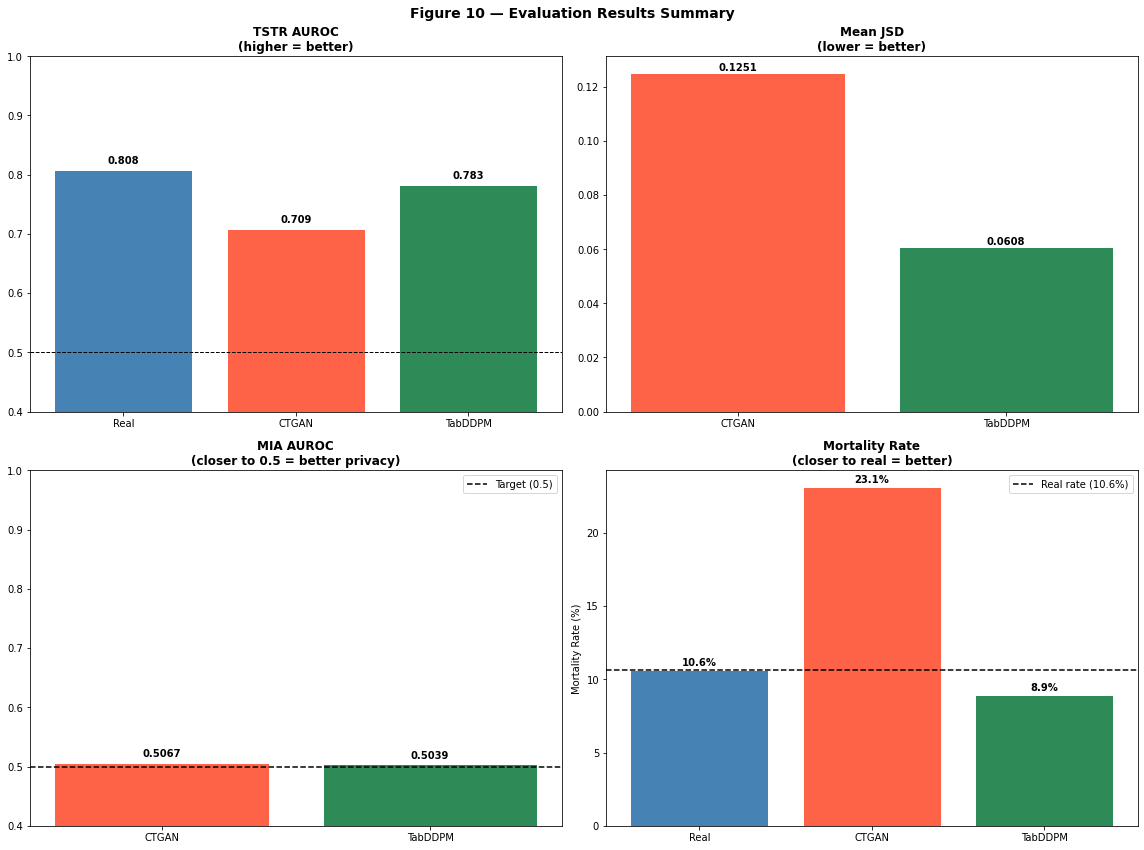

 Evaluation summary chart saved


In [11]:
# Visual summary of key metrics

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# TSTR AUROC
auroc_vals = [
    tstr_df[tstr_df['Training Data']=='Real (upper bound)']['AUROC'].values[0],
    tstr_df[tstr_df['Training Data']=='CTGAN']['AUROC'].values[0],
    tstr_df[tstr_df['Training Data']=='TabDDPM']['AUROC'].values[0]
]
axes[0,0].bar(['Real', 'CTGAN', 'TabDDPM'], auroc_vals,
              color=['steelblue', 'tomato', 'seagreen'],
              edgecolor='white')
axes[0,0].set_title('TSTR AUROC\n(higher = better)',
                     fontsize=12, fontweight='bold')
axes[0,0].set_ylim(0.4, 1.0)
axes[0,0].axhline(0.5, color='black', linestyle='--',
                  linewidth=1, label='Random baseline')
for i, v in enumerate(auroc_vals):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}',
                   ha='center', fontweight='bold')

# Mean JSD
jsd_vals = [jsd_df['ctgan_jsd'].mean(), jsd_df['tabddpm_jsd'].mean()]
axes[0,1].bar(['CTGAN', 'TabDDPM'], jsd_vals,
              color=['tomato', 'seagreen'], edgecolor='white')
axes[0,1].set_title('Mean JSD\n(lower = better)',
                     fontsize=12, fontweight='bold')
for i, v in enumerate(jsd_vals):
    axes[0,1].text(i, v + 0.001, f'{v:.4f}',
                   ha='center', fontweight='bold')

# MIA AUROC
mia_vals = [mia_results['CTGAN'], mia_results['TabDDPM']]
axes[1,0].bar(['CTGAN', 'TabDDPM'], mia_vals,
              color=['tomato', 'seagreen'], edgecolor='white')
axes[1,0].axhline(0.5, color='black', linestyle='--',
                  linewidth=1.5, label='Target (0.5)')
axes[1,0].set_title('MIA AUROC\n(closer to 0.5 = better privacy)',
                     fontsize=12, fontweight='bold')
axes[1,0].set_ylim(0.4, 1.0)
axes[1,0].legend()
for i, v in enumerate(mia_vals):
    axes[1,0].text(i, v + 0.01, f'{v:.4f}',
                   ha='center', fontweight='bold')

# Mortality rate comparison
mort_vals = [10.6, 23.1, 8.9]
axes[1,1].bar(['Real', 'CTGAN', 'TabDDPM'], mort_vals,
              color=['steelblue', 'tomato', 'seagreen'],
              edgecolor='white')
axes[1,1].axhline(10.6, color='black', linestyle='--',
                  linewidth=1.5, label='Real rate (10.6%)')
axes[1,1].set_title('Mortality Rate\n(closer to real = better)',
                     fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Mortality Rate (%)')
axes[1,1].legend()
for i, v in enumerate(mort_vals):
    axes[1,1].text(i, v + 0.3, f'{v}%',
                   ha='center', fontweight='bold')

plt.suptitle('Figure 10 — Evaluation Results Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'evaluation_summary.png'),
            bbox_inches='tight')
plt.show()
print(" Evaluation summary chart saved")

## Notebook 06 — Evaluation Complete

### Three-Pillar Evaluation Framework

| Pillar | Metrics Used |
|--------|-------------|
| Fidelity | JSD, MMD, Frobenius norm, column statistics |
| Utility | TSTR AUROC, TSTR AUPRC, ROC curves |
| Privacy | MIA AUROC, DCR 5th percentile |

### Figures Produced
| Figure | Description |
|--------|-------------|
| Fig 7  | Correlation matrix comparison |
| Fig 8  | TSTR ROC curves |
| Fig 9  | DCR distribution |
| Fig 10 | Evaluation summary bar charts |

### Output Files
- `results/column_statistics.csv`
- `results/jsd_scores.csv`
- `results/tstr_results.csv`
- `results/final_results_summary.csv`